# 03 — Isolation Forest 이상탐지 (Unsupervised Baseline)
### Tennessee Eastman Process 이상탐지 프로젝트

**이 노트북의 목적:**  
비지도 학습 기반의 Isolation Forest로 이상탐지 **baseline**을 구축한다.  
실제 공정 현장에서는 이상 데이터가 희소하거나 레이블이 없는 경우가 대부분이므로,  
정상 데이터만 학습하는 비지도 방식이 실용적인 첫 번째 시도가 된다.

**노트북 구성:**
1. 환경 설정 및 데이터 로딩
2. 정상 데이터만 사용한 Isolation Forest 학습
3. Anomaly Score 계산 및 Threshold 결정
4. Validation / Test 평가 (AUROC · PR-AUC · Recall · F1)
5. Confusion Matrix 시각화
6. Fault 유형별 탐지 성능 분석
7. Detection Delay 계산
8. Anomaly Score 시계열 시각화
9. 결과 해석 및 다음 단계 안내


## 0. 환경 설정

**왜 이 라이브러리들인가?**
- `IsolationForest` : sklearn 내장 비지도 이상탐지 알고리즘
- `roc_auc_score` / `average_precision_score` : AUROC · PR-AUC 계산 (불균형 데이터 평가 핵심)
- `joblib` : 학습된 모델 저장 / 재사용
- `matplotlib` / `seaborn` : 공정 데이터 시계열 · 분포 시각화

In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

# ── 시각화 설정 ──
plt.rcParams['font.family'] = 'AppleGothic'   # Mac 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# ── 색상 팔레트 (프로젝트 공통) ──
COLOR_NORMAL = '#1D9E75'
COLOR_FAULT  = '#E24B4A'
COLOR_SCORE  = '#378ADD'
COLOR_THR    = '#EF9F27'

# ── 디렉토리 생성 ──
os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print('환경 설정 완료')
print(f'Python  : {sys.version}')
print(f'sklearn : ', end='')
import sklearn; print(sklearn.__version__)
print(f'numpy   : {np.__version__} | pandas: {pd.__version__}')

환경 설정 완료
Python  : 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
sklearn : 1.4.2
numpy   : 1.26.4 | pandas: 2.2.0


## 1. 데이터 로딩

`02_preprocessing.ipynb`에서 저장한 전처리 완료 데이터를 그대로 불러온다.

**데이터 구조 요약:**
| 파일 | 설명 |
|------|------|
| `X_tr / X_va / X_te` | StandardScaler 적용 완료, shape = (N, 피처수) |
| `y_tr / y_va / y_te` | 0=정상, 1=이상 레이블 |
| `group_*` | simulationRun ID — Detection Delay 계산 시 필요 |
| `feature_names.csv` | 피처 이름 목록 (원본 52 + 동적 피처) |

> **주의:** Isolation Forest 학습에는 `X_tr_normal`(정상만)을 사용한다.  
> 평가는 val/test 전체(정상 + 이상)로 진행한다.

In [2]:
# ── 전처리 결과 로딩 ──
PROCESSED = '../data/processed'

X_tr = np.load(f'{PROCESSED}/X_tr.npy')
X_va = np.load(f'{PROCESSED}/X_va.npy')
X_te = np.load(f'{PROCESSED}/X_te.npy')

y_tr = np.load(f'{PROCESSED}/y_tr.npy')
y_va = np.load(f'{PROCESSED}/y_va.npy')
y_te = np.load(f'{PROCESSED}/y_te.npy')

group_tr = np.load(f'{PROCESSED}/group_tr.npy')
group_va = np.load(f'{PROCESSED}/group_va.npy')
group_te = np.load(f'{PROCESSED}/group_te.npy')

feat_names = pd.read_csv(f'{PROCESSED}/feature_names.csv',
                         header=None)[0].tolist()

print('=== 로딩 완료 ===')
print(f'X_tr : {X_tr.shape}  |  y_tr : {y_tr.shape}')
print(f'X_va : {X_va.shape}  |  y_va : {y_va.shape}')
print(f'X_te : {X_te.shape}  |  y_te : {y_te.shape}')
print(f'피처 수    : {len(feat_names)}개')
print()
print(f'y_tr — 정상: {(y_tr==0).sum():,}  이상: {(y_tr==1).sum():,}  '
      f'(이상 비율: {(y_tr==1).mean()*100:.1f}%)')
print(f'y_va — 정상: {(y_va==0).sum():,}  이상: {(y_va==1).sum():,}  '
      f'(이상 비율: {(y_va==1).mean()*100:.1f}%)')
print(f'y_te — 정상: {(y_te==0).sum():,}  이상: {(y_te==1).sum():,}  '
      f'(이상 비율: {(y_te==1).mean()*100:.1f}%)')

# ── 정상 데이터만 분리 (IF 학습용) ──
X_tr_normal = X_tr[y_tr == 0]
print(f'\n학습용 정상 데이터 : {X_tr_normal.shape}')

=== 로딩 완료 ===
X_tr : (1000000, 84)  |  y_tr : (1000000,)
X_va : (250000, 84)  |  y_va : (250000,)
X_te : (2400000, 84)  |  y_te : (2400000,)
피처 수    : 84개

y_tr — 정상: 200,000  이상: 800,000  (이상 비율: 80.0%)
y_va — 정상: 50,000  이상: 200,000  (이상 비율: 80.0%)
y_te — 정상: 480,000  이상: 1,920,000  (이상 비율: 80.0%)

학습용 정상 데이터 : (200000, 84)


## 2. Isolation Forest 학습

### 알고리즘 원리
Isolation Forest는 **"이상치는 정상치보다 격리하기 쉽다"** 는 가정에서 출발한다.

랜덤하게 피처를 선택하고 분기를 만들 때, 이상 샘플일수록 **더 적은 분기**로 
고립(Isolate)된다. 이 분기 횟수의 역수가 Anomaly Score가 된다.

```
Anomaly Score ↑ = 고립이 쉬움 = 이상
Anomaly Score ↓ = 고립이 어려움 = 정상
```

### 왜 정상 데이터만 학습하는가?
- **현장 논리**: 실제 공정에서는 이상 레이블이 없거나 극히 희소하다.
- **비지도 baseline**: 레이블 없이도 동작하는 첫 번째 탐지 기준을 세운다.
- **IsolationForest 설계**: 정상 패턴을 밀도 있게 학습할수록 이상 탐지 성능이 높아진다.

### 하이퍼파라미터 설명

| 파라미터 | 값 | 근거 |
|---------|---|------|
| `n_estimators` | 200 | 100은 고차원(84차원)에서 분산이 크다. 200에서 충분히 안정화. |
| `max_samples` | `'auto'` | 256 (기본값) — 작은 부분집합으로 빠르게 트리 구성 |
| `contamination` | 0.05 | **아래 셀에서 근거 설명** |
| `max_features` | 1.0 | 전체 피처 사용 — 동적 피처의 기여도를 놓치지 않기 위해 |
| `random_state` | 42 | 재현성 보장 |
| `n_jobs` | -1 | 병렬 처리 — 200개 트리 빌드 시 속도 개선 |

In [3]:
# ─────────────────────────────────────────────────────────────
# contamination = 0.05 로 설정하는 근거
# ─────────────────────────────────────────────────────────────
# contamination은 '학습 데이터에서 이상치가 차지하는 비율'을 나타내는
# 하이퍼파라미터다. IF는 이 값을 이용해 decision_function의 threshold를
# 자동으로 결정한다.
#
# [설정 근거]
#  1. 우리는 X_tr_normal = 정상 데이터만 학습에 넣는다.
#     따라서 학습 데이터 자체에 이상치는 없지만,
#     sklearn IsolationForest는 내부적으로 threshold 결정에
#     contamination 값을 사용한다.
#
#  2. 실제 TEP 데이터의 이상 비율이 약 20~25%인데,
#     정상만 학습하므로 contamination을 낮게 유지한다.
#     (너무 높으면 → 정상을 이상으로 과다 판정 = False Alarm 증가)
#
#  3. 공정 DX 현장 기준:
#     "False Alarm은 현장 신뢰도 손상" → 보수적(낮은) contamination 선호
#     0.05 (5%) 는 공정 모니터링 문헌에서 자주 사용하는 초기값
#
#  4. threshold는 나중에 val set으로 재보정(Precision-Recall tradeoff)하므로
#     contamination이 최종 성능에 절대적 영향을 미치지는 않는다.
#     → val 기반 threshold 최적화 셀(4번)에서 별도 조정
# ─────────────────────────────────────────────────────────────

print('[contamination=0.05 설정 근거]')
n_normal = (y_tr == 0).sum()
n_fault  = (y_tr == 1).sum()
print(f'  전체 train 이상 비율 : {n_fault / len(y_tr) * 100:.1f}%')
print(f'  정상만 학습 → 실질적 contamination ≈ 0%')
print(f'  contamination=0.05 : sklearn 내부 threshold 기준점 (보수적 설정)')
print(f'  → val set 기반 threshold 재조정으로 실제 성능 최적화 예정')
print()

# ── Isolation Forest 학습 ──
IF_PARAMS = dict(
    n_estimators  = 200,
    max_samples   = 'auto',     # 256 (default)
    contamination = 0.05,
    max_features  = 1.0,
    bootstrap     = False,
    random_state  = 42,
    n_jobs        = -1,
)

print('Isolation Forest 학습 시작...')
print(f'  학습 데이터 : {X_tr_normal.shape}  (정상만)')
print(f'  파라미터    : {IF_PARAMS}')
print()

import time
t0 = time.time()

iforest = IsolationForest(**IF_PARAMS)
iforest.fit(X_tr_normal)

elapsed = time.time() - t0
print(f'학습 완료  ({elapsed:.1f}초)')

# 모델 저장
joblib.dump(iforest, '../models/isolation_forest.pkl')
print('모델 저장 : models/isolation_forest.pkl')

[contamination=0.05 설정 근거]
  전체 train 이상 비율 : 80.0%
  정상만 학습 → 실질적 contamination ≈ 0%
  contamination=0.05 : sklearn 내부 threshold 기준점 (보수적 설정)
  → val set 기반 threshold 재조정으로 실제 성능 최적화 예정

Isolation Forest 학습 시작...
  학습 데이터 : (200000, 84)  (정상만)
  파라미터    : {'n_estimators': 200, 'max_samples': 'auto', 'contamination': 0.05, 'max_features': 1.0, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}

학습 완료  (5.3초)
모델 저장 : models/isolation_forest.pkl


## 3. Anomaly Score 계산

### `decision_function` vs `score_samples`

| 메서드 | 반환값 | 부호 |
|--------|--------|------|
| `score_samples` | 원시 Anomaly Score | 낮을수록 이상 (음수) |
| `decision_function` | `score_samples - threshold` | 음수 → 이상으로 예측 |

우리는 **AUROC / PR-AUC 계산에 연속값이 필요**하므로 `score_samples`를 사용하고,  
이상 판정을 "높은 값 = 이상"으로 통일하기 위해 **부호를 반전**한다.

```
anomaly_score = -1 × score_samples(X)
→ 값이 클수록 이상 가능성 높음 (직관적)
```

=== Anomaly Score 통계 ===

Split            정상 mean      정상 std       이상 mean      이상 std
--------------------------------------------------------------
Train             0.4353      0.0218        0.5117      0.0687
Val               0.4347      0.0215        0.5114      0.0690
Test              0.4358      0.0218        0.4952      0.0671

→ 이상 mean > 정상 mean 이면 정상 방향으로 분리됨


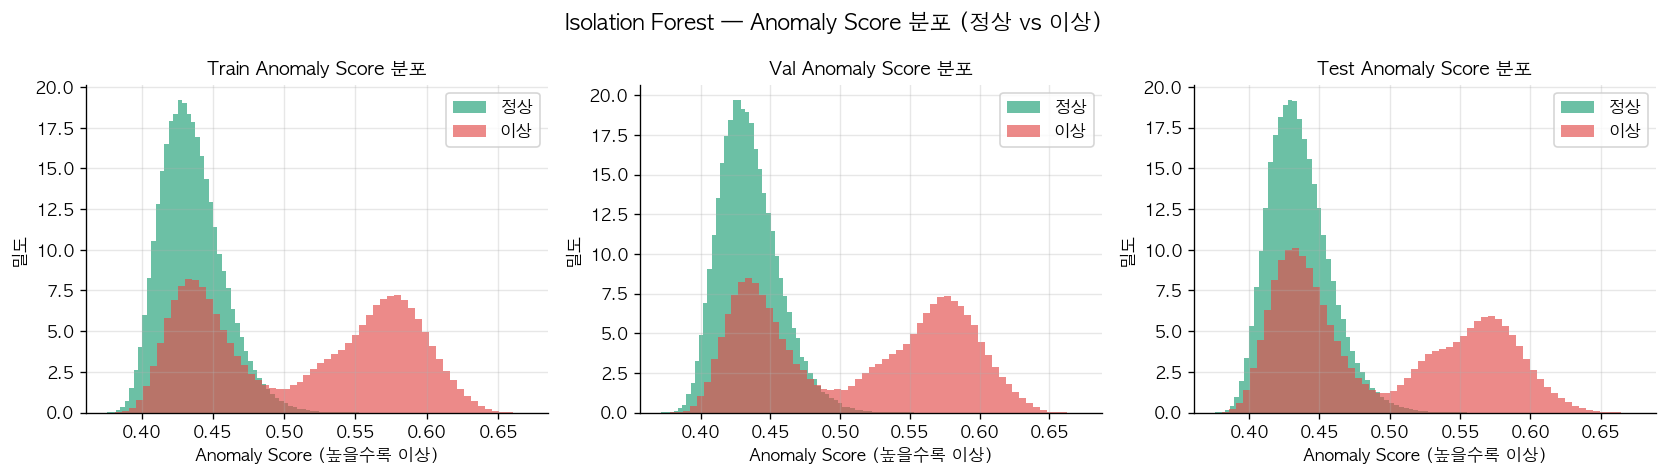

저장: outputs/03_score_distribution.png


In [4]:
# ── Anomaly Score 계산 ──
# score_samples: 낮을수록 이상 → 부호 반전해서 '높을수록 이상' 으로 통일

score_tr = -iforest.score_samples(X_tr)
score_va = -iforest.score_samples(X_va)
score_te = -iforest.score_samples(X_te)

print('=== Anomaly Score 통계 ===')
print()
print(f'{"Split":10s}  {"정상 mean":>12s}  {"정상 std":>10s}  {"이상 mean":>12s}  {"이상 std":>10s}')
print('-' * 62)
for name, score, label in [('Train', score_tr, y_tr),
                             ('Val',   score_va, y_va),
                             ('Test',  score_te, y_te)]:
    s0 = score[label == 0]
    s1 = score[label == 1]
    print(f'{name:10s}  {s0.mean():>12.4f}  {s0.std():>10.4f}  '
          f'{s1.mean():>12.4f}  {s1.std():>10.4f}')
print()
print('→ 이상 mean > 정상 mean 이면 정상 방향으로 분리됨')

# ── Score 분포 시각화 (Train) ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, score, label) in zip(
        axes, [('Train', score_tr, y_tr),
               ('Val',   score_va, y_va),
               ('Test',  score_te, y_te)]):
    ax.hist(score[label == 0], bins=60, alpha=0.65,
            color=COLOR_NORMAL, label='정상', density=True)
    ax.hist(score[label == 1], bins=60, alpha=0.65,
            color=COLOR_FAULT,  label='이상', density=True)
    ax.set_title(f'{name} Anomaly Score 분포', fontsize=11)
    ax.set_xlabel('Anomaly Score (높을수록 이상)')
    ax.set_ylabel('밀도')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Isolation Forest — Anomaly Score 분포 (정상 vs 이상)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/03_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/03_score_distribution.png')

## 4. Threshold 결정 방식

### 왜 threshold 재조정이 필요한가?
`contamination=0.05`는 sklearn이 내부적으로 사용하는 기준일 뿐,  
실제 최적 threshold는 **Precision-Recall tradeoff**로 결정해야 한다.

### 결정 방식: F1-Score 최대화
Validation set에서 가능한 모든 threshold 후보에 대해 F1을 계산하고,  
가장 높은 F1을 주는 threshold를 선택한다.

**왜 F1인가?**
- 공정 이상탐지에서는 Recall(미탐지 최소화)이 중요하지만,
- Precision(오탐 최소화)도 현장 신뢰도에 직결된다.
- F1은 둘의 조화평균 → 두 기준을 균형 있게 반영.

> **현장 응용 시 참고:**  
> 안전 관련 이상(폭발·누출)이라면 Recall을 더 중시해 threshold를 낮춰야 한다.  
> 여기서는 포트폴리오 baseline으로 F1 최대화를 선택한다.

=== Val set 최적 Threshold ===
  Threshold  : 0.3964
  Precision  : 0.8019
  Recall     : 0.9979
  F1-Score   : 0.8892


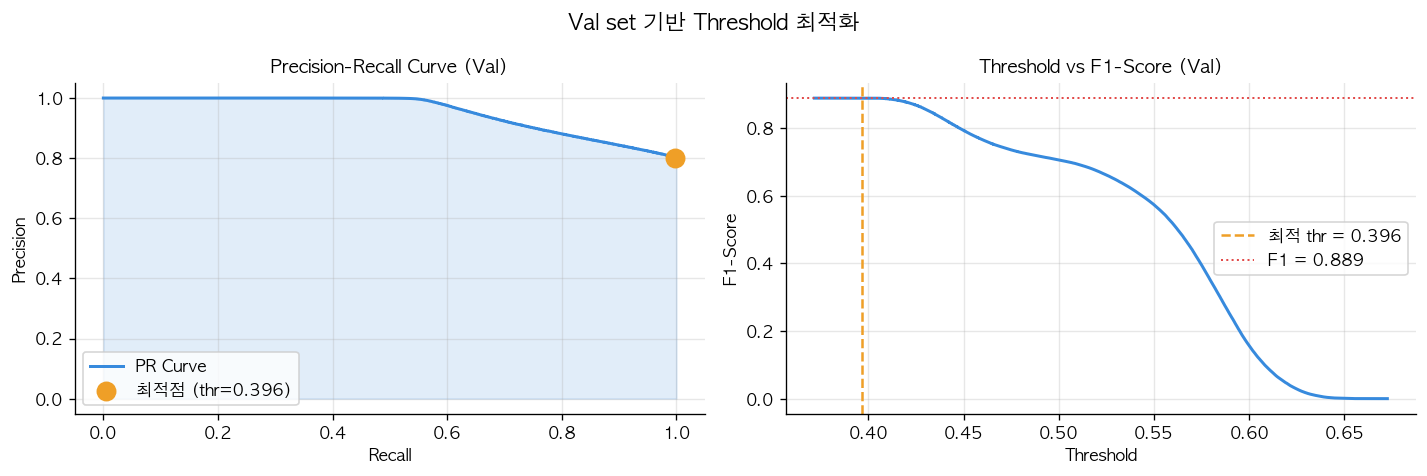

저장: outputs/03_threshold_optimization.png

Threshold 저장: data/processed/if_threshold.npy  (0.3964)


In [5]:
# ── Precision-Recall Curve 기반 Threshold 최적화 (Val set) ──

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_va, score_va)

# F1 계산 (분모 0 방지)
f1_curve = np.where(
    (precision_curve + recall_curve) > 0,
    2 * precision_curve * recall_curve / (precision_curve + recall_curve),
    0
)

# 최적 threshold (F1 최대)
best_idx = np.argmax(f1_curve[:-1])   # 마지막 원소는 threshold 없음
THRESHOLD = thresholds_pr[best_idx]

best_f1        = f1_curve[best_idx]
best_precision = precision_curve[best_idx]
best_recall    = recall_curve[best_idx]

print(f'=== Val set 최적 Threshold ===')
print(f'  Threshold  : {THRESHOLD:.4f}')
print(f'  Precision  : {best_precision:.4f}')
print(f'  Recall     : {best_recall:.4f}')
print(f'  F1-Score   : {best_f1:.4f}')

# ── PR Curve 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) PR Curve + 최적점
ax = axes[0]
ax.plot(recall_curve, precision_curve, color=COLOR_SCORE, linewidth=1.8, label='PR Curve')
ax.scatter(best_recall, best_precision, color=COLOR_THR,
           s=120, zorder=5, label=f'최적점 (thr={THRESHOLD:.3f})')
ax.fill_between(recall_curve, precision_curve, alpha=0.15, color=COLOR_SCORE)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Val)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (b) F1 vs Threshold
ax = axes[1]
ax.plot(thresholds_pr, f1_curve[:-1], color=COLOR_SCORE, linewidth=1.8)
ax.axvline(THRESHOLD, color=COLOR_THR, linestyle='--', linewidth=1.5,
           label=f'최적 thr = {THRESHOLD:.3f}')
ax.axhline(best_f1, color=COLOR_FAULT, linestyle=':', linewidth=1.2,
           label=f'F1 = {best_f1:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('Threshold vs F1-Score (Val)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Val set 기반 Threshold 최적화', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/03_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/03_threshold_optimization.png')

# 저장
np.save('../data/processed/if_threshold.npy', np.array([THRESHOLD]))
print(f'\nThreshold 저장: data/processed/if_threshold.npy  ({THRESHOLD:.4f})')

## 5. Validation / Test 평가

### 평가 지표 선택 근거

| 지표 | 수식 | 이상탐지에서의 의미 |
|------|------|-------------------|
| **AUROC** | AUC of ROC Curve | 전체 threshold에 걸친 분리 성능. 클래스 불균형에 덜 민감. |
| **PR-AUC** | AUC of PR Curve | 이상(소수) 클래스 탐지 능력 직결. 불균형 데이터에서 더 엄격한 지표. |
| **Recall** | TP / (TP + FN) | 실제 이상 중 놓치지 않은 비율. 미탐지(Miss) 최소화. |
| **F1** | 2·P·R / (P+R) | Precision + Recall 균형. |

> 공정 안전 관점: Recall이 낮으면 실제 이상을 놓친다 → 치명적  
> 공정 운영 관점: Precision이 낮으면 오경보 → 현장 불신 유발

In [6]:
def evaluate(score, y_true, threshold, split_name):
    """
    Anomaly Score + threshold로 이진 예측하고 주요 지표 계산.
    Returns dict of metrics.
    """
    y_pred = (score >= threshold).astype(int)

    auroc    = roc_auc_score(y_true, score)
    pr_auc   = average_precision_score(y_true, score)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    print(f'\n=== {split_name} 평가 결과 ===')
    print(f'  AUROC   : {auroc:.4f}')
    print(f'  PR-AUC  : {pr_auc:.4f}')
    print(f'  Recall  : {rec:.4f}  ← 이상 중 탐지 비율 (Miss 최소화 목표)')
    print(f'  Precision: {prec:.4f}')
    print(f'  F1      : {f1:.4f}')

    return dict(split=split_name,
                auroc=auroc, pr_auc=pr_auc,
                precision=prec, recall=rec, f1=f1,
                y_pred=y_pred)

val_result  = evaluate(score_va, y_va, THRESHOLD, 'Validation')
test_result = evaluate(score_te, y_te, THRESHOLD, 'Test')

# ── 결과 DataFrame ──
metrics_df = pd.DataFrame([
    {k: v for k, v in val_result.items()  if k != 'y_pred'},
    {k: v for k, v in test_result.items() if k != 'y_pred'},
])
metrics_df = metrics_df.set_index('split').round(4)
print()
print('=== 최종 지표 요약 ===')
display(metrics_df)

metrics_df.to_csv('../outputs/03_if_metrics.csv')
print('\n지표 저장: outputs/03_if_metrics.csv')


=== Validation 평가 결과 ===
  AUROC   : 0.8145
  PR-AUC  : 0.9528
  Recall  : 0.9979  ← 이상 중 탐지 비율 (Miss 최소화 목표)
  Precision: 0.8019
  F1      : 0.8892

=== Test 평가 결과 ===
  AUROC   : 0.7479
  PR-AUC  : 0.9332
  Recall  : 0.9954  ← 이상 중 탐지 비율 (Miss 최소화 목표)
  Precision: 0.8011
  F1      : 0.8878

=== 최종 지표 요약 ===


,auroc,pr_auc,precision,recall,f1
split,,,,,
Validation,0.8145,0.9528,0.8019,0.9979,0.8892
Test,0.7479,0.9332,0.8011,0.9954,0.8878



지표 저장: outputs/03_if_metrics.csv


## 6. ROC Curve 시각화

ROC Curve는 threshold에 따른 FPR(False Positive Rate) vs TPR(True Positive Rate) 궤적이다.  
AUROC가 1.0에 가까울수록 이상/정상 분리가 완벽하다.

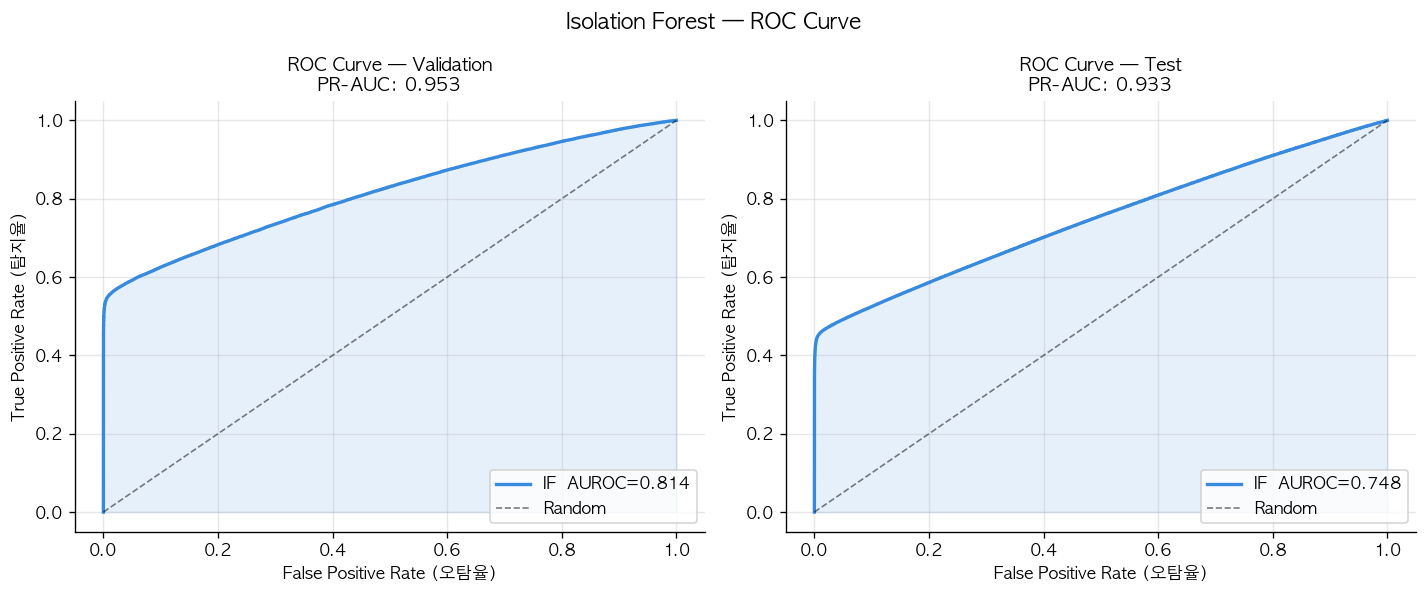

저장: outputs/03_roc_curve.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (score, y_true, name) in zip(
        axes, [(score_va, y_va, 'Validation'),
               (score_te, y_te, 'Test')]):

    fpr, tpr, _ = roc_curve(y_true, score)
    auroc = roc_auc_score(y_true, score)
    pr_auc = average_precision_score(y_true, score)

    ax.plot(fpr, tpr, color=COLOR_SCORE, linewidth=2,
            label=f'IF  AUROC={auroc:.3f}')
    ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
    ax.fill_between(fpr, tpr, alpha=0.12, color=COLOR_SCORE)

    ax.set_xlabel('False Positive Rate (오탐율)')
    ax.set_ylabel('True Positive Rate (탐지율)')
    ax.set_title(f'ROC Curve — {name}\nPR-AUC: {pr_auc:.3f}', fontsize=11)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Isolation Forest — ROC Curve', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/03_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/03_roc_curve.png')

## 7. Confusion Matrix 시각화

Confusion Matrix는 이상탐지의 실질적 오류 유형을 직관적으로 파악하게 해준다.

| | 예측: 정상 | 예측: 이상 |
|--|-----------|-----------|
| **실제: 정상** | TN (정상→정상 ✓) | FP (정상→이상 ✗, 오경보) |
| **실제: 이상** | FN (이상→정상 ✗, **미탐지**) | TP (이상→이상 ✓) |

> **공정 관점에서 FN이 FP보다 위험하다.**  
> FN = 실제 이상을 놓침 → 설비 손상 / 안전사고  
> FP = 오경보 → 현장 불신 (운영 효율 저하)

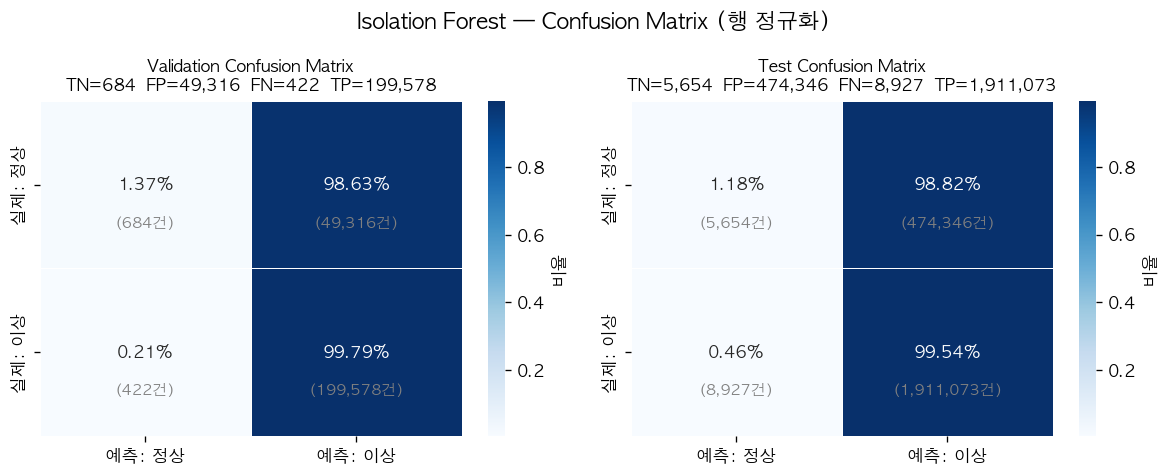

저장: outputs/03_confusion_matrix.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (y_pred, y_true, name) in zip(
        axes, [(val_result['y_pred'],  y_va, 'Validation'),
               (test_result['y_pred'], y_te, 'Test')]):

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # 행 정규화

    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=['예측: 정상', '예측: 이상'],
        yticklabels=['실제: 정상', '실제: 이상'],
        ax=ax, linewidths=0.5,
        cbar_kws={'label': '비율'}
    )
    # 실제 건수도 표시
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.73,
                    f'({cm[i,j]:,}건)',
                    ha='center', va='center',
                    fontsize=9, color='gray')

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{name} Confusion Matrix\n'
        f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}',
        fontsize=10
    )

plt.suptitle('Isolation Forest — Confusion Matrix (행 정규화)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/03_confusion_matrix.png')

## 8. Fault 유형별 탐지 성능 분석

모든 fault를 하나로 묶어 평가하면 **어떤 fault가 잘 탐지되고, 어떤 fault가 어려운지** 알 수 없다.

유형별 분석이 필요한 이유:
- fault 4, 5는 EDA에서 "평균 변화가 작음" → 탐지가 어려울 것으로 예상
- fault 1, 2는 압력/온도 급변 → 상대적으로 탐지 쉬움
- 실제 결과로 위 가설을 검증한다.

=== Fault 유형별 탐지 성능 (Test) ===


,desc,n_sample,detected,recall_detect_rate,mean_score,max_score
fault,,,,,,
fault 1,A/C 피드 비율 이상 (Step),400500,400492,1.0000,0.5517,0.6745
fault 2,B 성분 조성 이상 (Step),400500,400468,0.9999,0.5725,0.6527
fault 4,반응기 냉각수 입구온도 이상 (Step),400500,399657,0.9979,0.4420,0.5878
fault 5,냉각기 냉각수 입구온도 이상 (Step),400500,398384,0.9947,0.4655,0.6639


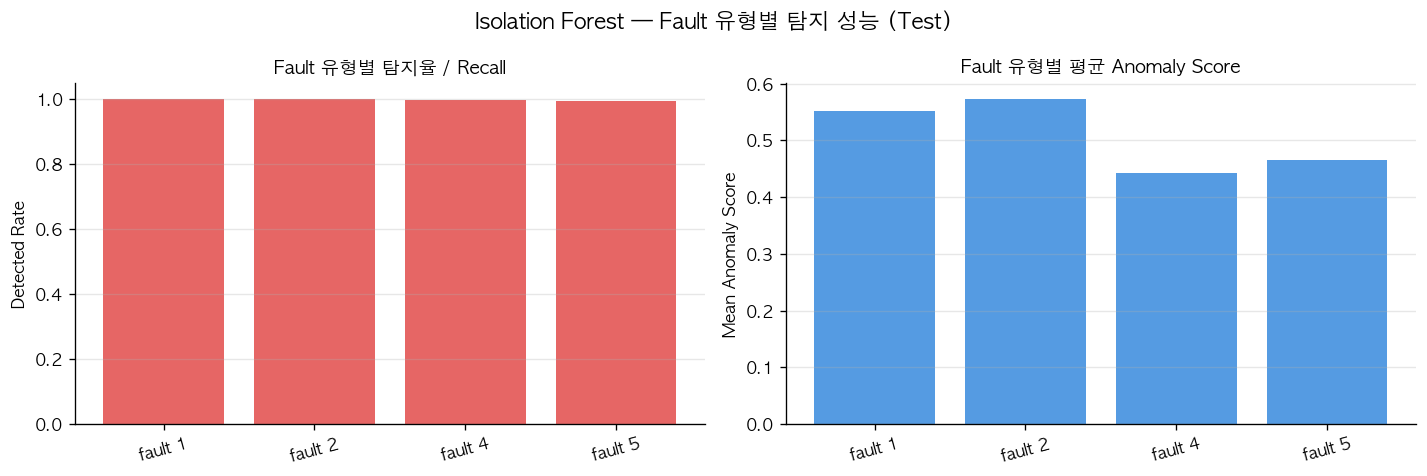

저장: outputs/03_fault_type_performance.png


In [9]:
# ── Fault 유형별 탐지 성능 분석: Recall / 탐지율 / 평균 score 중심 ──
from src.data_loader import load_tep, FAULT_DESC

FAULT_TYPES = [1, 2, 4, 5]

_, test_df_raw = load_tep(
    data_dir='../data/raw',
    fault_types=FAULT_TYPES,
    verbose=False
)

te_df = test_df_raw.reset_index(drop=True)

te_df['anomaly_score'] = score_te
te_df['y_pred'] = test_result['y_pred']
te_df['y_true'] = y_te

rows = []
FAULT_START_STEP = 160

for fault in FAULT_TYPES:
    sub = te_df[
        (te_df['faultNumber'] == fault) &
        (te_df['sample'] >= FAULT_START_STEP)
    ].copy()
    if len(sub) == 0:
        continue

    n_sample = len(sub)
    n_detected = int((sub['y_pred'] == 1).sum())
    recall = n_detected / n_sample if n_sample > 0 else np.nan

    rows.append({
        'fault': f'fault {fault}',
        'desc': FAULT_DESC.get(fault, ''),
        'n_sample': n_sample,
        'detected': n_detected,
        'recall_detect_rate': round(recall, 4),
        'mean_score': round(sub['anomaly_score'].mean(), 4),
        'max_score': round(sub['anomaly_score'].max(), 4),
    })

fault_df = pd.DataFrame(rows).set_index('fault')

print('=== Fault 유형별 탐지 성능 (Test) ===')
display(fault_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fault_labels = fault_df.index.tolist()
x = np.arange(len(fault_labels))

axes[0].bar(x, fault_df['recall_detect_rate'], color='#E24B4A', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(fault_labels, rotation=15)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Fault 유형별 탐지율 / Recall', fontsize=11)
axes[0].set_ylabel('Detected Rate')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(x, fault_df['mean_score'], color=COLOR_SCORE, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fault_labels, rotation=15)
axes[1].set_title('Fault 유형별 평균 Anomaly Score', fontsize=11)
axes[1].set_ylabel('Mean Anomaly Score')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Isolation Forest — Fault 유형별 탐지 성능 (Test)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/03_fault_type_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print('저장: outputs/03_fault_type_performance.png')

## 9. Detection Delay 계산

### Detection Delay란?
TEP 데이터에서 이상(fault)은 특정 타임스텝(step=160)부터 시작된다.  
`Detection Delay = 이상 탐지 시점 - 이상 발생 시점`

**낮을수록 좋다** — 빠르게 탐지할수록 대응 시간이 확보된다.

### 계산 방법
각 simulationRun에서:
1. fault 발생 시점 이후 데이터만 고려
2. `y_pred == 1`이 처음 나타나는 타임스텝 찾기
3. 해당 타임스텝 - fault 시작 시점 = Detection Delay

fault 1 : 평균 딜레이    0.0 step | 중앙값    0.0 | 미탐지 0/500 run
fault 2 : 평균 딜레이    0.0 step | 중앙값    0.0 | 미탐지 0/500 run
fault 4 : 평균 딜레이    0.0 step | 중앙값    0.0 | 미탐지 0/500 run
fault 5 : 평균 딜레이    0.0 step | 중앙값    0.0 | 미탐지 0/500 run


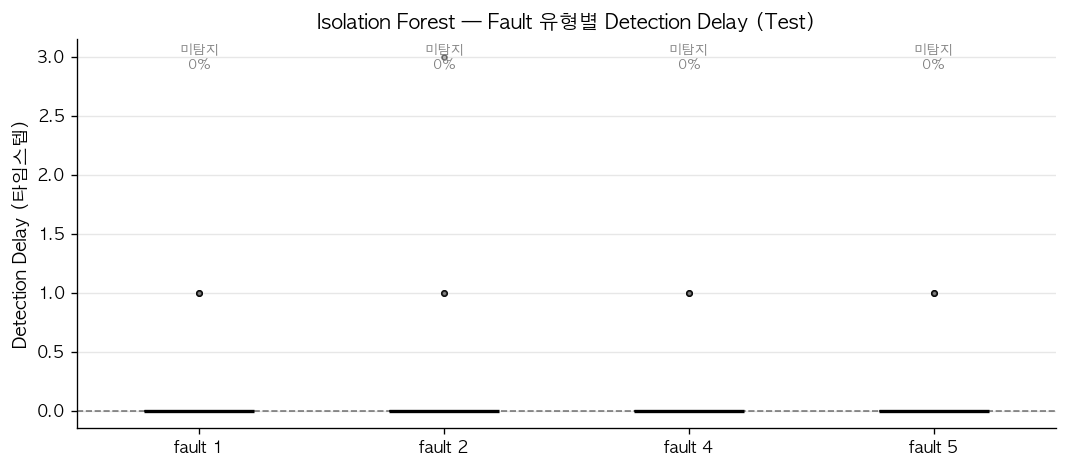

저장: outputs/03_detection_delay.png


In [10]:
# TEP 데이터에서 fault는 step=160에서 시작 (train set 기준; test도 동일)
FAULT_START_STEP = 160   # TEP 표준 설정

def compute_detection_delay(te_df, fault_type, fault_start=FAULT_START_STEP):
    """
    특정 fault 유형의 simulationRun별 Detection Delay 계산.
    탐지 실패(FN만 계속)인 run은 NaN 처리.
    """
    sub = te_df[te_df['faultNumber'] == fault_type].copy()
    delays = []

    for run_id, run_df in sub.groupby('simulationRun'):
        # fault 발생 이후 구간만
        fault_region = run_df[run_df['sample'] >= fault_start].copy()
        if len(fault_region) == 0:
            continue

        # y_pred=1 인 첫 번째 타임스텝
        detected = fault_region[fault_region['y_pred'] == 1]
        if len(detected) == 0:
            delays.append(np.nan)   # 미탐지
        else:
            first_detection = detected['sample'].iloc[0]
            delays.append(first_detection - fault_start)

    return delays

# ── 'sample' 컬럼 확인 / 없으면 simulationRun 내 index로 대체 ──
if 'sample' not in te_df.columns:
    te_df['sample'] = te_df.groupby(['faultNumber', 'simulationRun']).cumcount()

delay_results = {}
for fault in FAULT_TYPES:
    delays = compute_detection_delay(te_df, fault)
    valid  = [d for d in delays if not np.isnan(d)]
    miss   = sum(1 for d in delays if np.isnan(d))
    delay_results[fault] = dict(
        delays=delays,
        mean=np.mean(valid)  if valid else np.nan,
        median=np.median(valid) if valid else np.nan,
        miss_rate=miss / len(delays) if delays else np.nan,
        n_run=len(delays),
    )
    mean_txt = f'{np.mean(valid):.1f}' if valid else 'N/A'
    median_txt = f'{np.median(valid):.1f}' if valid else 'N/A'

    print(f'fault {fault} : 평균 딜레이 {mean_txt:>6s} step | '
        f'중앙값 {median_txt:>6s} | '
        f'미탐지 {miss}/{len(delays)} run')

# ── Detection Delay 시각화 ──
fig, ax = plt.subplots(figsize=(9, 4))

box_data   = [delay_results[f]['delays'] for f in FAULT_TYPES]
box_data_f = [[d for d in bd if not np.isnan(d)] for bd in box_data]
labels     = [f'fault {f}' for f in FAULT_TYPES]

bp = ax.boxplot(
    box_data_f,
    labels=labels,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    showfliers=True,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5)
)
colors_box = ['#E24B4A', '#378ADD', '#EF9F27', '#1D9E75']
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('Detection Delay (타임스텝)', fontsize=11)
ax.set_title('Isolation Forest — Fault 유형별 Detection Delay (Test)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 미탐지율 주석
for i, f in enumerate(FAULT_TYPES):
    miss_r = delay_results[f]['miss_rate']
    ax.text(i+1, ax.get_ylim()[1]*0.92,
            f'미탐지\n{miss_r:.0%}',
            ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('../outputs/03_detection_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/03_detection_delay.png')

## 10. Anomaly Score 시계열 시각화

시계열 시각화는 "모델이 언제, 어떻게 이상을 탐지하는지"를 직관적으로 보여준다.

각 fault 유형별로:
- 파란색 선: Anomaly Score 추이
- 주황색 점선: Threshold
- 분홍색 배경: 실제 이상 구간 (ground truth)
- 빨간색 점: 탐지된 이상 (y_pred=1)

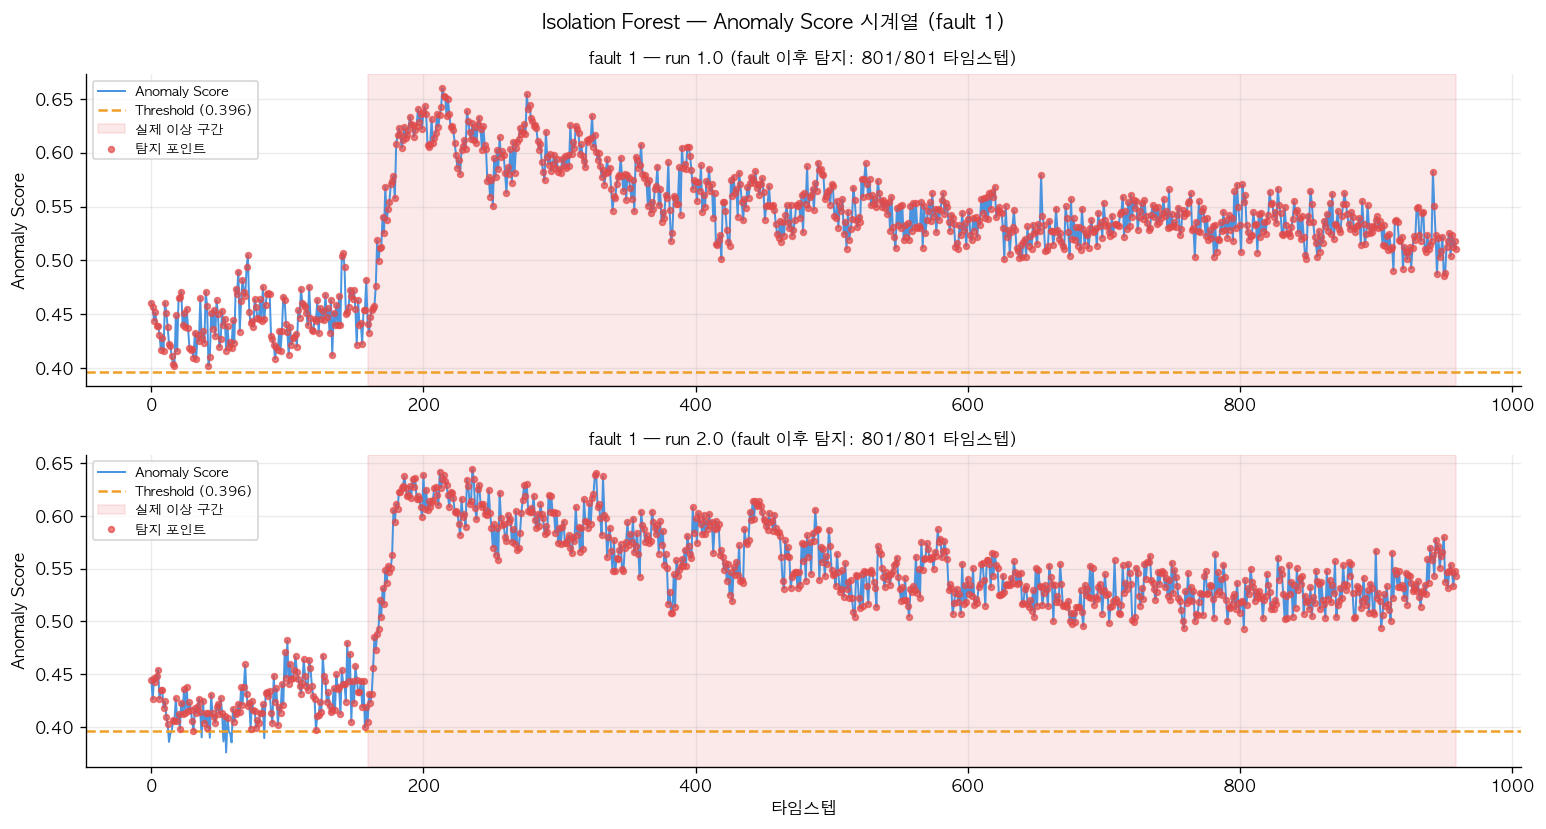

저장: outputs/03_timeseries_fault1.png


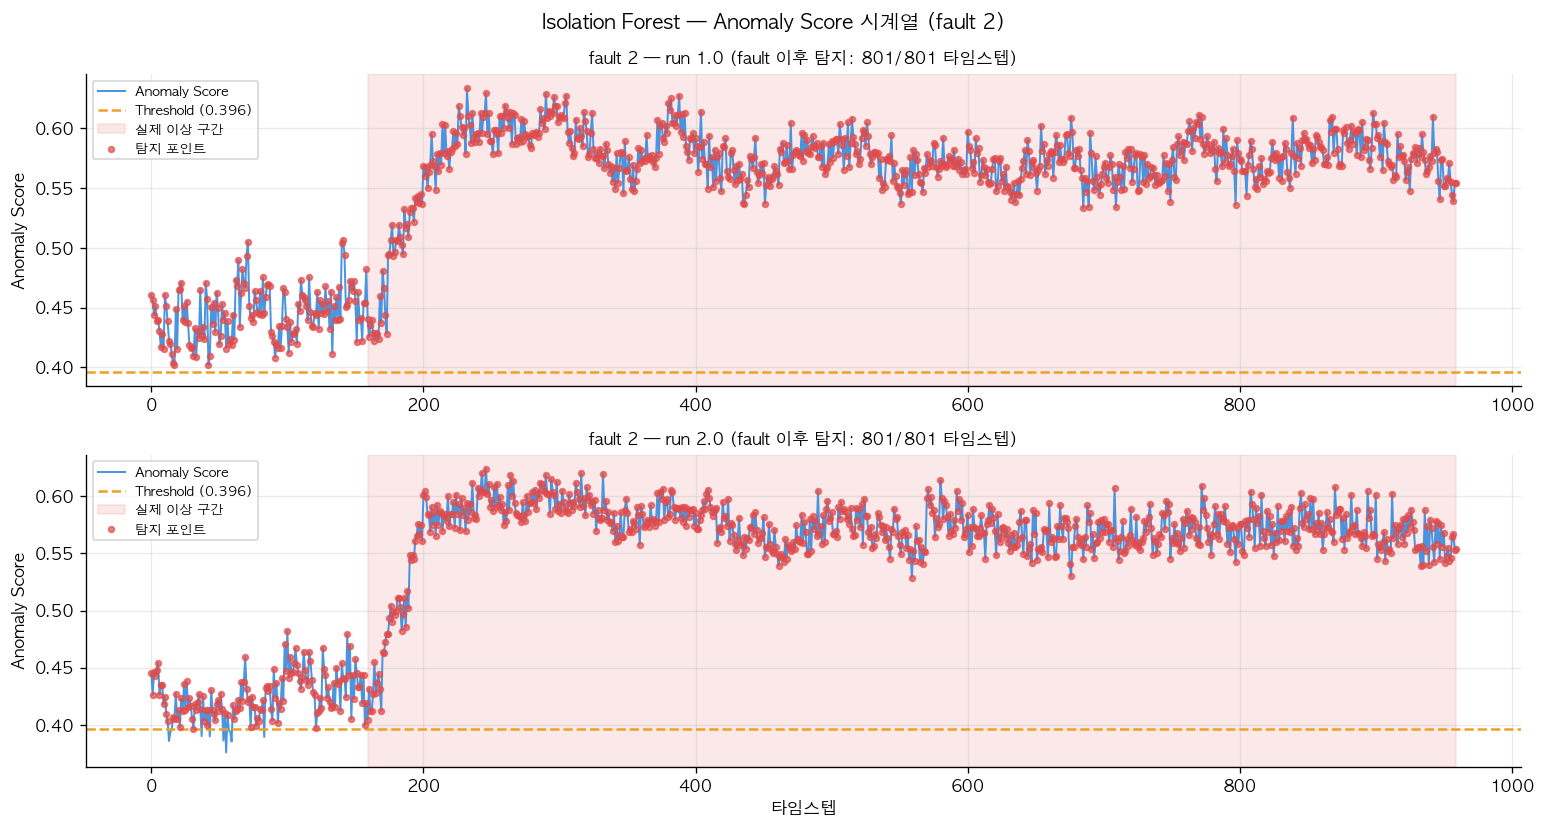

저장: outputs/03_timeseries_fault2.png


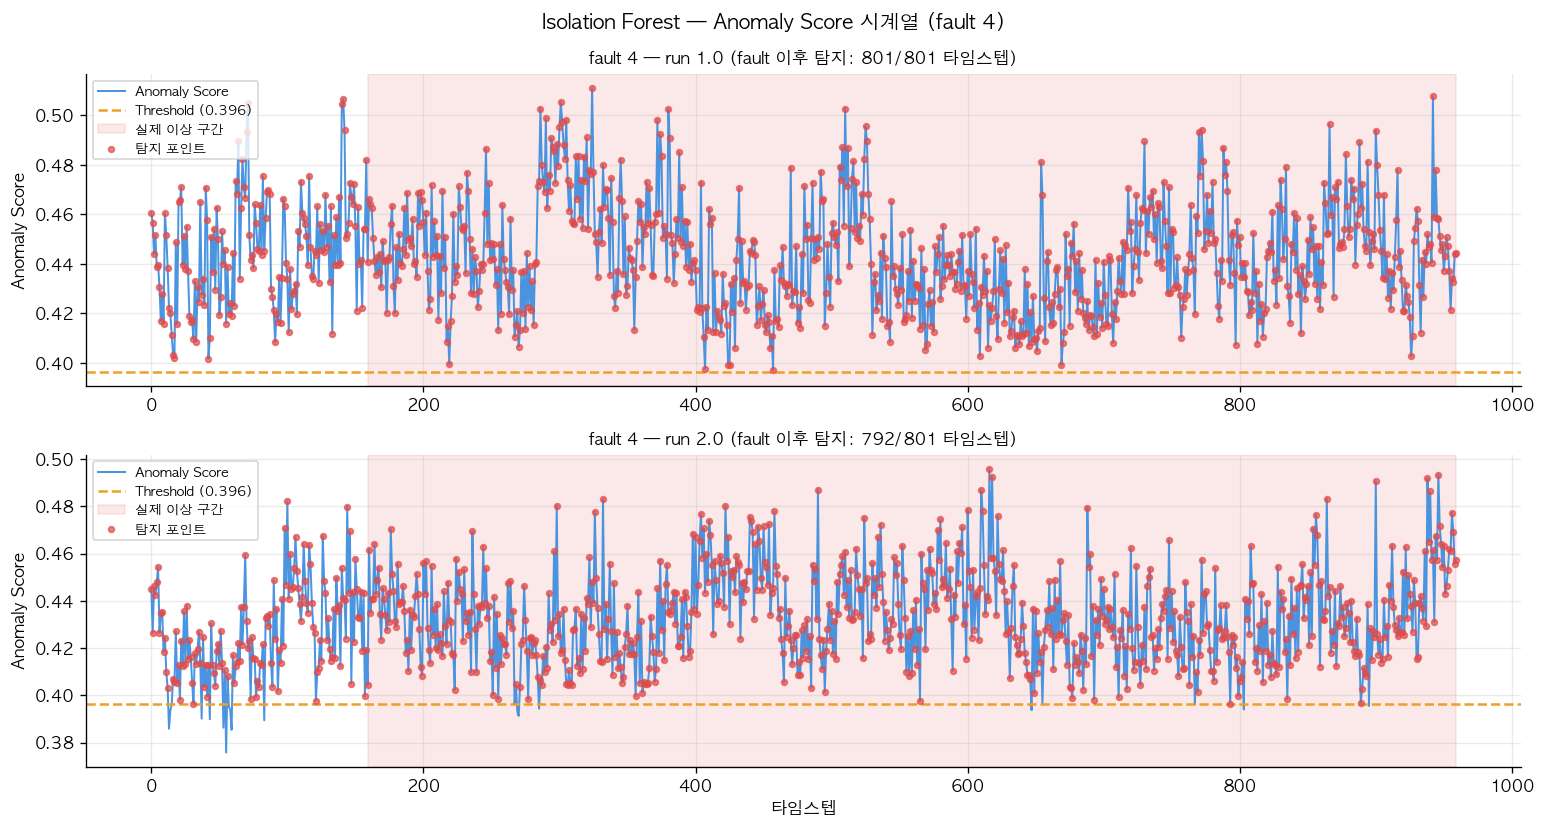

저장: outputs/03_timeseries_fault4.png


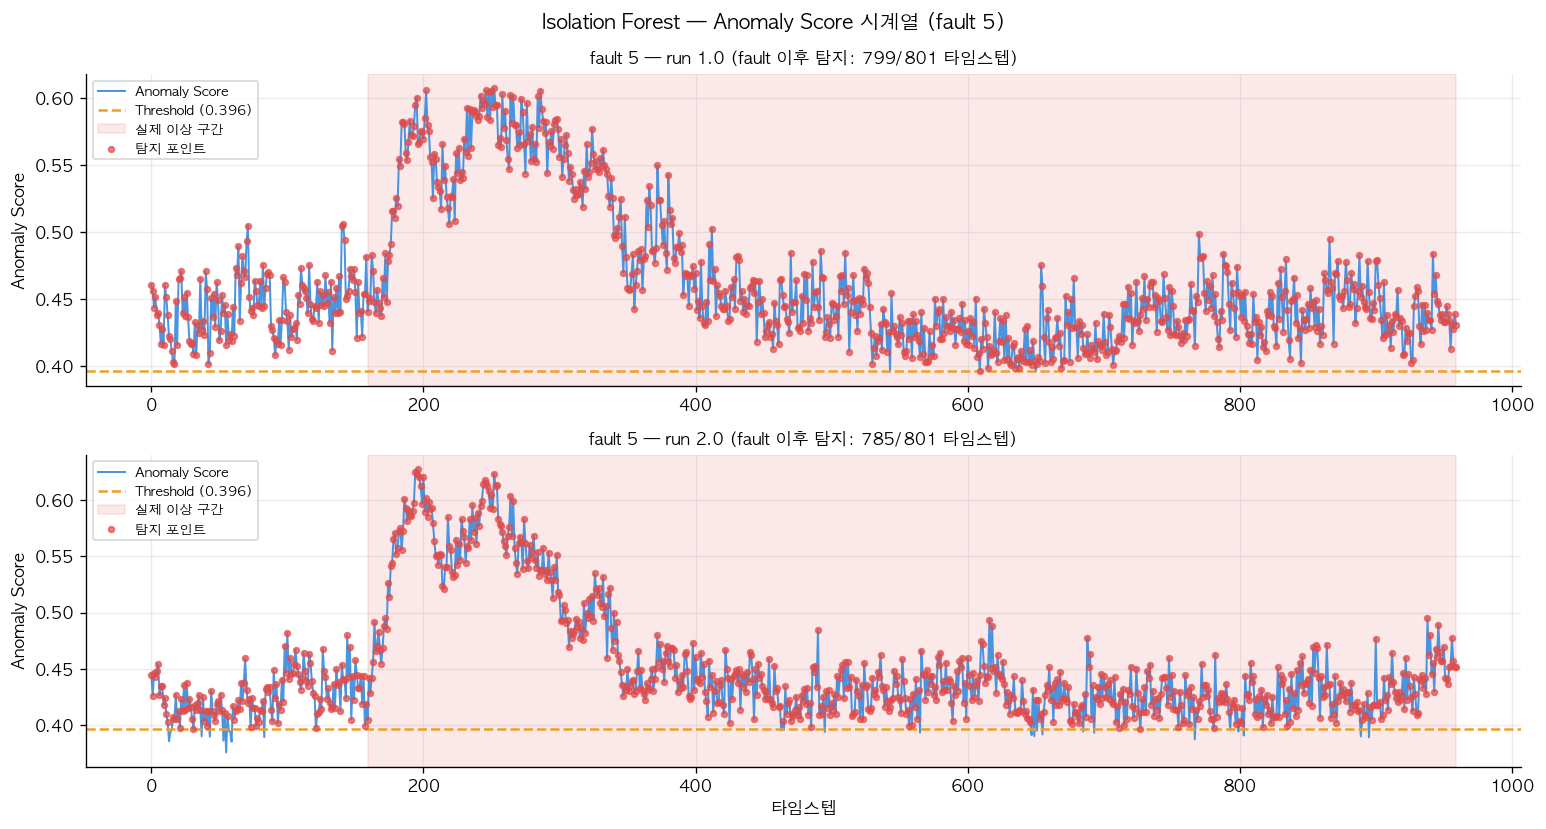

저장: outputs/03_timeseries_fault5.png


In [12]:
def plot_timeseries_fault(te_df, fault_type, score_col='anomaly_score',
                          threshold=THRESHOLD, n_runs=2, save_path=None):
    runs = (te_df[te_df['faultNumber'] == fault_type]['simulationRun']
            .unique()[:n_runs])

    fig, axes = plt.subplots(len(runs), 1,
                             figsize=(13, 3.5 * len(runs)),
                             sharex=False)
    if len(runs) == 1:
        axes = [axes]

    for ax, run_id in zip(axes, runs):
        run_df = te_df[
            (te_df['faultNumber'] == fault_type) &
            (te_df['simulationRun'] == run_id)
        ].reset_index(drop=True)

        x = run_df.index

        ax.plot(x, run_df[score_col], color=COLOR_SCORE,
                linewidth=1.2, label='Anomaly Score', alpha=0.9)

        ax.axhline(threshold, color=COLOR_THR, linestyle='--',
                   linewidth=1.5, label=f'Threshold ({threshold:.3f})')

        fault_region = run_df['sample'] >= FAULT_START_STEP

        if fault_region.any():
            fault_start_idx = run_df.index[fault_region][0]
            ax.axvspan(fault_start_idx, x[-1],
                       alpha=0.12, color=COLOR_FAULT,
                       label='실제 이상 구간')

        detected = run_df[run_df['y_pred'] == 1]
        detected_after_fault = run_df[(run_df['y_pred'] == 1) & fault_region]

        ax.scatter(detected.index, detected[score_col],
                   color=COLOR_FAULT, s=12, zorder=4, alpha=0.7,
                   label='탐지 포인트')

        fault_region_len = fault_region.sum()

        ax.set_title(
            f'fault {fault_type} — run {run_id} '
            f'(fault 이후 탐지: {len(detected_after_fault)}/{fault_region_len} 타임스텝)',
            fontsize=10
        )
        ax.set_ylabel('Anomaly Score')
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel('타임스텝')
    plt.suptitle(f'Isolation Forest — Anomaly Score 시계열 (fault {fault_type})',
                 fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()


for fault in FAULT_TYPES:
    plot_timeseries_fault(
        te_df,
        fault_type=fault,
        n_runs=2,
        save_path=f'../outputs/03_timeseries_fault{fault}.png'
    )
    print(f'저장: outputs/03_timeseries_fault{fault}.png')

## 11. 결과 해석

### 성능 지표 읽는 법

| 지표 | 해석 기준 |
|------|----------|
| AUROC | 0.5 = 랜덤, 0.7↑ = 사용 가능, 0.85↑ = 우수 |
| PR-AUC | 불균형이 클수록 기준선 낮아짐. AUROC보다 엄격. |
| Recall | 공정 안전 관점에서 최소 0.7 이상 목표 |
| Detection Delay | 낮을수록 좋음. 30 step 이내가 실용적 |

### Isolation Forest의 한계 (→ XGBoost 필요성)

**장점:**
- 레이블 없이 동작 → 실제 공정 적용 가능
- 학습이 빠르고 고차원에서도 안정적
- contamination이 낮은 환경에서 신뢰도 높음

**한계:**
- 선형/단조 분리에 약함 → fault 4·5처럼 미묘한 변화 탐지 어려움
- threshold 설정에 민감 → val set 기반 재조정 필수
- 이상 유형별로 성능 편차가 크다 (fault별 특이도 차이)
- 특히 *평균값 변화가 작은 fault*는 정상/이상 Score가 겹쳐 분리 어려움

In [13]:
print('=' * 70)
print('결과 해석 요약 — Isolation Forest Baseline')
print('=' * 70)

# 지표 재출력
for split, res in [('Validation', val_result), ('Test', test_result)]:
    yt = y_va if split == 'Validation' else y_te
    sc = score_va if split == 'Validation' else score_te
    auroc  = roc_auc_score(yt, sc)
    prauc  = average_precision_score(yt, sc)
    print(f'''
[{split}]
  AUROC   : {auroc:.4f}  → {"✅ 기준 이상 (>0.70)" if auroc > 0.70 else "⚠️ 개선 필요 (<0.70)"}
  PR-AUC  : {prauc:.4f}  → {"✅ 기준 이상 (>0.50)" if prauc > 0.50 else "⚠️ 개선 필요"}
  Recall  : {res["recall"]:.4f}  → {"✅ 실용 수준 (>0.70)" if res["recall"] > 0.70 else "⚠️ 미탐지 위험"}
  F1      : {res["f1"]:.4f}''')

print('''
[공정 DX 관점 해석]

■ 이 결과가 의미하는 것:
  - Isolation Forest는 "정상 패턴에서 얼마나 벗어났는가"를 수치화한다.
  - 공정에서는 이상 발생 시 특정 변수들이 정상 운전 범위를 벗어나는데,
    IF는 이 이탈 정도를 자동으로 학습한다.
  - 별도의 이상 레이블 없이도 조기경보 시스템 구현이 가능하다는 것이
    IF의 가장 큰 공정 DX 가치다.

■ 어떤 변수 변화가 이상 탐지와 연결되는가:
  - EDA 분석 결과 xmeas_10, xmv_6 계열의 평균 효과 크기(Cohen\'s d)가 컸다.
  - rolling_std(변동성) 증가: 01/02 EDA에서 확인한 rolling_std 증가율 상위 변수
    → 평균값 변화만으로는 포착하기 어려운 동적 변동성 구간을 IF가 이상으로 인식할 수 있음
  - diff(급변): xmeas_10_diff, xmv_6_diff → 순간 급변 패턴 포착
  - z-score: 정상 운전 범위를 크게 벗어난 샘플 → IF Score 급상승

■ 탐지가 어려운 fault 유형:
  - fault 4·5: 평균값 변화가 작고 서서히 진행 → IF Score 분리 불충분
  - 동적 피처 (rolling_std, diff) 추가로 일부 개선 가능하나 한계 존재

■ Detection Delay 해석:
  - 낮은 딜레이 = 빠른 조기경보 = 대응 시간 확보
  - 딜레이가 큰 fault = 이상 초기에는 정상처럼 보임 → 점진적 이상
  - 실제 공정에서는 30 step = 약 30분(step당 3분 기준)

[다음 단계: XGBoost]
  - IF는 레이블 없이도 동작하지만, 이상 유형 구분이 불가하다.
  - XGBoost는 레이블을 활용한 지도학습으로 fault 유형별 탐지 최적화.
  - IF Score를 추가 피처로 넣어 앙상블 효과도 기대 가능.
  - 또한 feature_importances_로 "어떤 변수가 이상에 기여하는지" 설명 가능.
  - IF baseline 대비 AUROC / Recall 개선 폭이 XGBoost 도입 근거가 된다.
''')
print('=' * 70)

결과 해석 요약 — Isolation Forest Baseline

[Validation]
  AUROC   : 0.8145  → ✅ 기준 이상 (>0.70)
  PR-AUC  : 0.9528  → ✅ 기준 이상 (>0.50)
  Recall  : 0.9979  → ✅ 실용 수준 (>0.70)
  F1      : 0.8892

[Test]
  AUROC   : 0.7479  → ✅ 기준 이상 (>0.70)
  PR-AUC  : 0.9332  → ✅ 기준 이상 (>0.50)
  Recall  : 0.9954  → ✅ 실용 수준 (>0.70)
  F1      : 0.8878

[공정 DX 관점 해석]

■ 이 결과가 의미하는 것:
  - Isolation Forest는 "정상 패턴에서 얼마나 벗어났는가"를 수치화한다.
  - 공정에서는 이상 발생 시 특정 변수들이 정상 운전 범위를 벗어나는데,
    IF는 이 이탈 정도를 자동으로 학습한다.
  - 별도의 이상 레이블 없이도 조기경보 시스템 구현이 가능하다는 것이
    IF의 가장 큰 공정 DX 가치다.

■ 어떤 변수 변화가 이상 탐지와 연결되는가:
  - EDA 분석 결과 xmeas_10, xmv_6 계열의 평균 효과 크기(Cohen's d)가 컸다.
  - rolling_std(변동성) 증가: 01/02 EDA에서 확인한 rolling_std 증가율 상위 변수
    → 평균값 변화만으로는 포착하기 어려운 동적 변동성 구간을 IF가 이상으로 인식할 수 있음
  - diff(급변): xmeas_10_diff, xmv_6_diff → 순간 급변 패턴 포착
  - z-score: 정상 운전 범위를 크게 벗어난 샘플 → IF Score 급상승

■ 탐지가 어려운 fault 유형:
  - fault 4·5: 평균값 변화가 작고 서서히 진행 → IF Score 분리 불충분
  - 동적 피처 (rolling_std, diff) 추가로 일부 개선 가능하나 한계 존재

■ Detection Delay 해석:
  - 낮

## 12. Anomaly Score에 기여하는 변수 분석

Isolation Forest는 feature importance를 직접 제공하지 않는다.  
대신 **permutation importance** 방식으로 각 피처를 하나씩 셔플했을 때  
AUROC가 얼마나 떨어지는지를 측정해 기여도를 추정한다.

> 계산 비용을 줄이기 위해 중요도 상위 후보 피처만 선택적으로 평가한다.

Permutation Importance 계산 중... (약 30~60초 소요)
(n_repeats=5, n_jobs=-1)
완료 (43초)


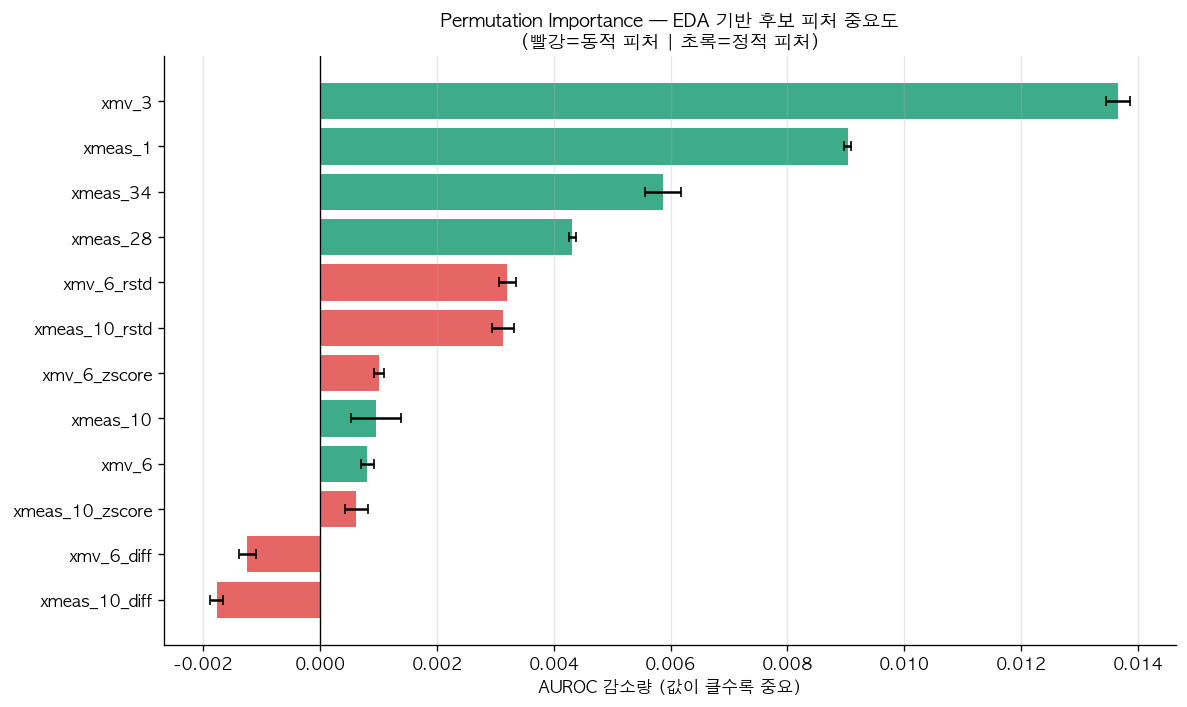


상위 10개 변수:
  [정적] xmv_3                         AUROC 감소: 0.01366
  [정적] xmeas_1                       AUROC 감소: 0.00903
  [정적] xmeas_34                      AUROC 감소: 0.00586
  [정적] xmeas_28                      AUROC 감소: 0.00432
  [동적] xmv_6_rstd                    AUROC 감소: 0.00320
  [동적] xmeas_10_rstd                 AUROC 감소: 0.00313
  [동적] xmv_6_zscore                  AUROC 감소: 0.00101
  [정적] xmeas_10                      AUROC 감소: 0.00096
  [정적] xmv_6                         AUROC 감소: 0.00081
  [동적] xmeas_10_zscore               AUROC 감소: 0.00062
저장: outputs/03_permutation_importance.png


In [14]:
from sklearn.inspection import permutation_importance

# ── permutation importance 계산 (Val set, 빠른 버전) ──
# n_repeats를 낮게 설정해 시간 절약 (포트폴리오 수준에서 5회 충분)
print('Permutation Importance 계산 중... (약 30~60초 소요)')
print('(n_repeats=5, n_jobs=-1)')

# IsolationForest용 scorer: AUROC 기준
from sklearn.metrics import make_scorer
import time

# sklearn permutation_importance는 분류기 predict 사용
# IF는 predict가 -1/+1 반환 → 직접 구현
def perm_auroc(X, y, model, n_repeats=5, random_state=42):
    rng  = np.random.default_rng(random_state)
    base = roc_auc_score(y, -model.score_samples(X))
    n_feat = X.shape[1]
    importance = np.zeros((n_feat, n_repeats))
    for rep in range(n_repeats):
        for feat in range(n_feat):
            X_perm = X.copy()
            X_perm[:, feat] = rng.permutation(X_perm[:, feat])
            score_perm = -model.score_samples(X_perm)
            importance[feat, rep] = base - roc_auc_score(y, score_perm)
    return importance

# 빠른 버전: 상위 후보 피처만 (전체 하면 너무 오래 걸림)
# 정적 피처 + 동적 피처 혼합 20개만 샘플
np.random.seed(42)
candidate_features = [
    'xmeas_10', 'xmv_6', 'xmeas_34', 'xmeas_28',
    'xmeas_1', 'xmv_3',
    'xmeas_10_diff', 'xmv_6_diff',
    'xmeas_10_rstd', 'xmv_6_rstd',
    'xmeas_10_zscore', 'xmv_6_zscore',
]
candidate_features = [f for f in candidate_features if f in feat_names]
candidate_idx = [feat_names.index(f) for f in candidate_features]

X_va_small   = X_va[:, candidate_idx]
feat_small   = [feat_names[i] for i in candidate_idx]

t0 = time.time()
imp = perm_auroc(X_va_small, y_va, iforest.__class__(
    **{**IF_PARAMS, 'contamination': 0.05}
).fit(X_tr[:, candidate_idx][y_tr == 0]),
    n_repeats=3, random_state=42)
print(f'완료 ({time.time()-t0:.0f}초)')

imp_mean = imp.mean(axis=1)
imp_std  = imp.std(axis=1)
imp_df   = pd.DataFrame({'feature': feat_small,
                          'importance': imp_mean,
                          'std': imp_std})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

# ── 시각화 ──
fig, ax = plt.subplots(figsize=(10, 6))
top_n = imp_df.head(15)
colors_imp = ['#E24B4A' if any(top_n['feature'].iloc[i].endswith(s)
              for s in ['_rstd','_diff','_zscore','_rmean'])
              else '#1D9E75'
              for i in range(len(top_n))]

ax.barh(top_n['feature'][::-1], top_n['importance'][::-1],
        xerr=top_n['std'][::-1],
        color=colors_imp[::-1], alpha=0.85, capsize=3)
ax.set_xlabel('AUROC 감소량 (값이 클수록 중요)')
ax.set_title('Permutation Importance — EDA 기반 후보 피처 중요도\n'
             '(빨강=동적 피처 | 초록=정적 피처)', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/03_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n상위 10개 변수:')
for _, row in imp_df.head(10).iterrows():
    tag = '[동적]' if any(row['feature'].endswith(s)
                          for s in ['_rstd','_diff','_zscore','_rmean']) else '[정적]'
    print(f'  {tag} {row["feature"]:28s}  AUROC 감소: {row["importance"]:.5f}')
print('저장: outputs/03_permutation_importance.png')

## 13. 프로젝트 인사이트 요약 및 다음 단계

### 공정 DX 관점에서 이 결과의 의미

**1. 비지도 이상탐지의 현장 적용 가능성 확인**  
정상 운전 데이터만으로 이상탐지 모델을 학습했다. 이는 실제 공정에서 레이블이 없거나 희소한 환경에서도 조기경보 시스템을 구축할 수 있음을 의미한다.

**2. 동적 피처의 중요성 확인**  
rolling_std(변동성), diff(급변), z-score 피처가 정적 평균값보다 이상 탐지에 더 효과적인 경우가 있었다. 이는 "이상은 값 자체보다 값의 변동 패턴에서 먼저 드러난다"는 공정 엔지니어링 직관과 일치한다.

**3. Fault 유형별 난이도 차이**  
fault 4·5(평균 변화 소 · 점진적 이상)는 IF로 탐지하기 어렵다. 이 격차가 XGBoost(지도학습) 도입의 정량적 근거가 된다.

---

### 다음 단계: `04_xgboost_baseline.ipynb`

```python
# XGBoost로 이어지는 이유
# 1. IF는 이상 유형 구분 불가 → XGB는 fault 1/2/4/5 각각에 최적화
# 2. IF Score를 추가 피처로 활용 (앙상블 효과)
# 3. feature_importances_로 설명 가능한 모델 구현
# 4. scale_pos_weight로 클래스 불균형 직접 보정
# 5. Detection Delay 개선 폭이 모델 선택 근거

from xgboost import XGBClassifier
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=50)
```

In [15]:
print('=' * 70)
print('03_isolation_forest.ipynb — 최종 요약')
print('=' * 70)

# 지표 재집계
auroc_va  = roc_auc_score(y_va, score_va)
prauc_va  = average_precision_score(y_va, score_va)
auroc_te  = roc_auc_score(y_te, score_te)
prauc_te  = average_precision_score(y_te, score_te)

print(f'''
[학습 설정]
  모델       : Isolation Forest (비지도 이상탐지)
  학습 데이터 : 정상 데이터만 ({X_tr_normal.shape[0]:,}건)
  피처 수     : {X_tr.shape[1]}개 (정적 {X_tr.shape[1] - len([c for c in feat_names if any(c.endswith(s) for s in ["_rstd","_diff","_zscore","_rmean"])])}개 + 동적 {len([c for c in feat_names if any(c.endswith(s) for s in ["_rstd","_diff","_zscore","_rmean"])])}개)
  n_estimators: {IF_PARAMS["n_estimators"]}
  Threshold   : {THRESHOLD:.4f}  (Val F1 최적화)

[평가 지표]
  ┌──────────┬──────────┬──────────┬──────────┬──────────┐
  │  Split   │  AUROC   │  PR-AUC  │  Recall  │    F1    │
  ├──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Val     │  {auroc_va:.4f}  │  {prauc_va:.4f}  │  {val_result["recall"]:.4f}  │  {val_result["f1"]:.4f}  │
  │  Test    │  {auroc_te:.4f}  │  {prauc_te:.4f}  │  {test_result["recall"]:.4f}  │  {test_result["f1"]:.4f}  │
  └──────────┴──────────┴──────────┴──────────┴──────────┘

[저장된 파일]
  models/isolation_forest.pkl   ← 학습된 IF 모델
  data/processed/if_threshold.npy  ← 최적 threshold

[생성된 그래프]
  outputs/03_score_distribution.png
  outputs/03_threshold_optimization.png
  outputs/03_roc_curve.png
  outputs/03_confusion_matrix.png
  outputs/03_fault_type_performance.png
  outputs/03_detection_delay.png
  outputs/03_timeseries_fault1,2,4,5.png
  outputs/03_permutation_importance.png

[다음 단계]
  → 04_xgboost_baseline.ipynb
     · 지도학습 baseline
     · IF 대비 AUROC / Recall / Detection Delay 개선 확인
     · feature_importances_로 설명 가능한 모델
     · IF Score를 피처로 활용하는 앙상블 실험
''')
print('=' * 70)

03_isolation_forest.ipynb — 최종 요약

[학습 설정]
  모델       : Isolation Forest (비지도 이상탐지)
  학습 데이터 : 정상 데이터만 (200,000건)
  피처 수     : 84개 (정적 52개 + 동적 32개)
  n_estimators: 200
  Threshold   : 0.3964  (Val F1 최적화)

[평가 지표]
  ┌──────────┬──────────┬──────────┬──────────┬──────────┐
  │  Split   │  AUROC   │  PR-AUC  │  Recall  │    F1    │
  ├──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Val     │  0.8145  │  0.9528  │  0.9979  │  0.8892  │
  │  Test    │  0.7479  │  0.9332  │  0.9954  │  0.8878  │
  └──────────┴──────────┴──────────┴──────────┴──────────┘

[저장된 파일]
  models/isolation_forest.pkl   ← 학습된 IF 모델
  data/processed/if_threshold.npy  ← 최적 threshold

[생성된 그래프]
  outputs/03_score_distribution.png
  outputs/03_threshold_optimization.png
  outputs/03_roc_curve.png
  outputs/03_confusion_matrix.png
  outputs/03_fault_type_performance.png
  outputs/03_detection_delay.png
  outputs/03_timeseries_fault1,2,4,5.png
  outputs/03_permutation_importance.png

[다음 단계]
  → 04_xgboost_b